# 🎛️ Advanced Darkroom: Split-Filter Printing

### Welcome, Master Printers!
In previous labs, we learned that variable-contrast photographic papers contain several emulsion layers, each sensitive to different colors of light[cite: 3]. By changing the color of the enlarger light with filters, we can dictate the overall contrast of a print[cite: 3]. 

But what if a single filter cannot solve the problems of a difficult negative? What if the shadows need extreme, punchy contrast, but the highlights need soft, low contrast to retain delicate details? 

This is where the advanced technique of **Split-Filter Printing** comes into play. Instead of using one filter for the entire print, we expose the *same sheet of paper* multiple times using completely different filters[cite: 3].

## Step 1: The Theory of Selective Contrast
Split-filter printing is essentially a double exposure that allows you to change contrast selectively across the tonal range[cite: 3]. 

Here is how a master printer uses this technique in conjunction with dodging and burning:
* **The High-Contrast Exposure:** By using a harsh filter (like a #4.5 or #5), you can dodge the shadow areas to separate the low-value (dark) tones and give them distinct, rich blacks[cite: 3].
* **The Low-Contrast Exposure:** A second exposure with a soft filter (like a #0 or #1.5) produces a normal contrast throughout the rest of the image, allowing you to burn in bright highlights without them turning harsh or gray[cite: 3].

### ⚠️ The Golden Rule
Because you are exposing the exact same piece of paper twice, you must be incredibly careful not to bump or move the enlarger head when physically swapping the filters[cite: 3]. If the enlarger moves even a millimeter, you will get an out-of-register double exposure, resulting in a blurry, ruined print[cite: 3].

## Step 2: A Real-World Example (Double Arch)
Let's look at how the author handled a difficult negative of "Double Arch" in Arches National Park[cite: 3]. 

The original negative was good and had a full range of values, but the test print showed that the highlights were a bit too light[cite: 3]. Because of the complex shape of the sandstone arch, traditional dodging and burning with a single filter was incredibly difficult[cite: 3]. 

The split-filter solution:
1. **Exposure 1 (Low Contrast):** A **#1.5 filter** was used for a long base exposure of **30 seconds** at f/11[cite: 3]. This laid down a soft, detailed foundation for the highlights.
2. **Exposure 2 (High Contrast):** A **#4.5 filter** was used for a much shorter punch of **6 seconds** at f/11[cite: 3]. This snapped the deep shadows into pure black without destroying the delicate highlight foundation built in the first step.

The result is a print that looks normal in overall contrast, but possesses incredibly detailed shadows without looking "flat"[cite: 3].

## 💻 Step 3: Simulating the Split-Filter Process
Let's use Python to mathematically simulate what happens to a sheet of variable-contrast paper when we subject it to two separate, sequential exposures using opposite filters.

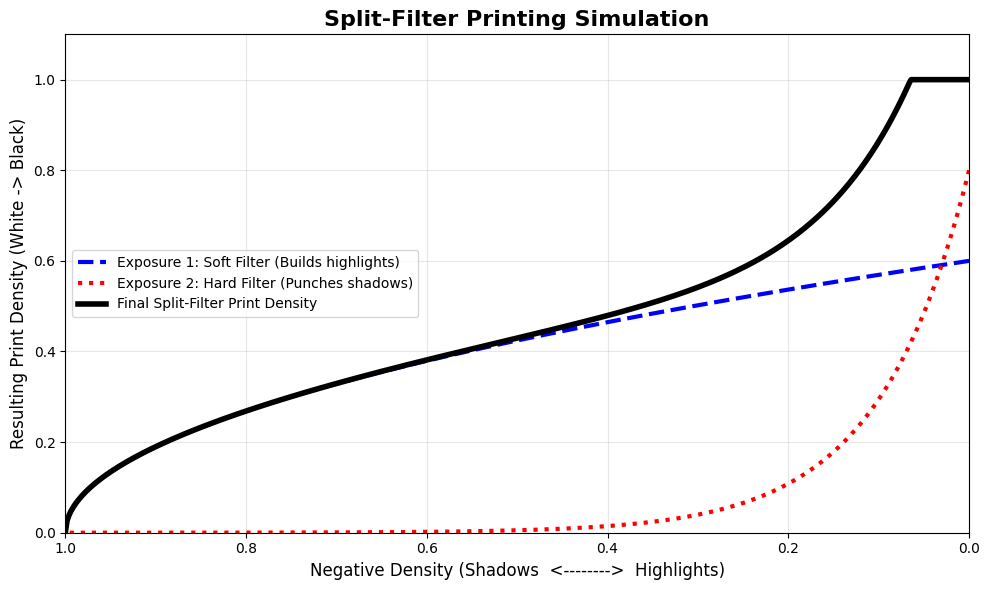

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_split_filter():
    """
    Simulates the additive process of Split-Filter Printing on variable contrast paper.
    We apply a low-contrast exposure (to build highlights) and a high-contrast 
    exposure (to snap the shadows) to a mock negative.
    """
    # 1. Create a mock 'negative' gradient (0 = clear film/shadows, 1 = dense film/highlights)
    negative_density = np.linspace(0, 1, 500)
    
    # 2. Simulate Exposure 1: Low Contrast (#1.5 Filter)
    # A long, soft exposure that slowly builds density across the whole range, 
    # but specifically targeting the dense highlights without blocking the shadows.
    exposure_0_soft = 0.6 * (1 - negative_density) ** 0.5 
    
    # 3. Simulate Exposure 2: High Contrast (#4.5 Filter)
    # A short, harsh punch of light that only affects the clearest parts of the negative (shadows),
    # rapidly pushing them to pure black while ignoring the highlights.
    exposure_5_hard = 0.8 * np.exp(-10 * negative_density)
    
    # 4. The Final Print (Photographic paper is an additive medium)
    final_print = exposure_0_soft + exposure_5_hard
    final_print = np.clip(final_print, 0, 1) # Paper cannot get darker than pure black (1.0)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(negative_density, exposure_0_soft, 'b--', lw=3, label="Exposure 1: Soft Filter (Builds highlights)")
    ax.plot(negative_density, exposure_5_hard, 'r:', lw=3, label="Exposure 2: Hard Filter (Punches shadows)")
    ax.plot(negative_density, final_print, 'k-', lw=4, label="Final Split-Filter Print Density")
    
    # Formatting
    ax.set_title("Split-Filter Printing Simulation", fontsize=16, fontweight='bold')
    ax.set_xlabel("Negative Density (Shadows  <-------->  Highlights)", fontsize=12)
    ax.set_ylabel("Resulting Print Density (White -> Black)", fontsize=12)
    
    # Invert X-axis because clear negative (0) yields black print (1)
    ax.invert_xaxis() 
    
    ax.set_xlim(1, 0)
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.legend(loc='center left')
    
    plt.tight_layout()
    plt.show()

# Run the split-filter simulator!
simulate_split_filter()